# import

In [1]:
import numpy as np
from neutron_geomcorr.geometry_correction import GeometryCorrection
import glob

import matplotlib.pyplot as plt
%matplotlib widget

from ipywidgets import widgets, interact

# initialize object 

In [2]:
list_tiff = glob.glob('data/tiff/homogeneous*.tif')

# initialize object
o_cgc = GeometryCorrection(list_files=list_tiff)
o_cgc.load_files(notebook=True)

Loading sample:   0%|          | 0/4 [00:00<?, ?it/s]

## Display images

interactive(children=(IntSlider(value=0, continuous_update=False, description='Image:', max=3), Output()), _do…

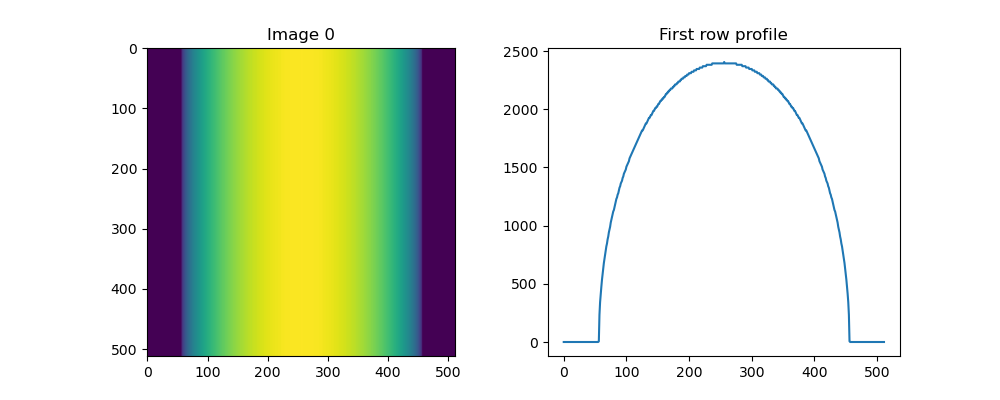

In [3]:
list_images = o_cgc.list_data

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
def plot(index):
    ax1.clear()
    ax1.imshow(list_images[index])
    ax1.set_title(f'Image {index}')
    
    ax2.clear()
    ax2.plot(list_images[index][0,:])
    ax2.set_title('First row profile')
    
    fig1.canvas.draw()

_ = interact(
    plot,
    index = widgets.IntSlider(
        value=0,
        min=0,
        max=len(list_images)-1,
        continuous_update=False,
        description='Image:'
    )
)

# Define parameters 

In [4]:
# center of cylinder
pixel_center = 256

# radius of cylinder
radius = 200

# define the parameters
o_cgc.define_parameters(outer_radius=radius, pixel_center=pixel_center)

# Run correction 

In [5]:
o_cgc.correct(notebook=True)

IntProgress(value=0, description='Progress:', max=4)

# Display data corrected 

interactive(children=(IntSlider(value=0, continuous_update=False, description='Image:', max=3), Output()), _do…

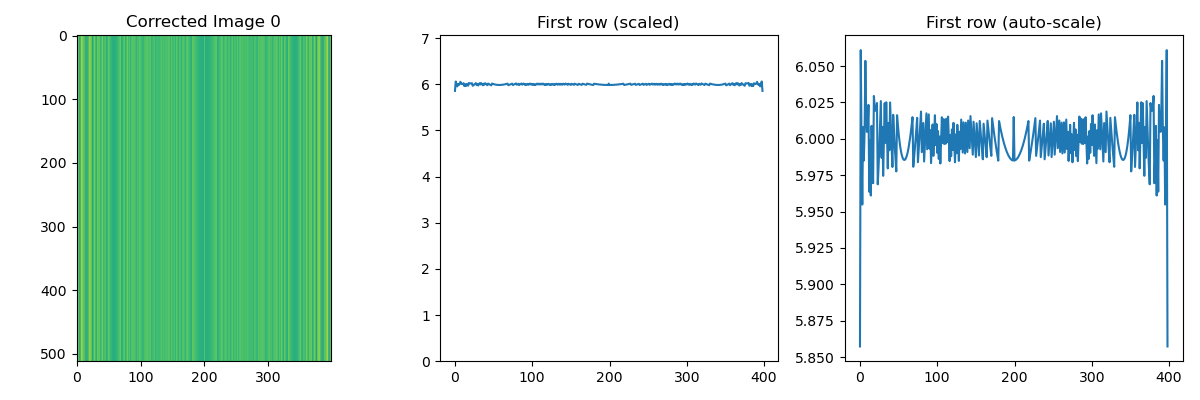

In [6]:
list_images_corrected = o_cgc.list_data_corrected

fig2, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
    
def plot_corrected(index):
    ax1.clear()
    ax1.imshow(list_images_corrected[index])
    ax1.set_title(f'Corrected Image {index}')
    
    ax2.clear()
    max_y_value = np.nanmax(list_images_corrected[index][0, 1:])
    ax2.plot(list_images_corrected[index][0,:])
    ax2.set_ylim(0, max_y_value+1)
    ax2.set_title('First row (scaled)')
    
    ax3.clear()
    ax3.plot(list_images_corrected[index][0,:])
    ax3.set_title('First row (auto-scale)')
    
    plt.tight_layout()
    fig2.canvas.draw()
    
_ = interact(
    plot_corrected,
    index = widgets.IntSlider(
        value=0,
        min=0,
        max=len(list_images_corrected)-1,
        continuous_update=False,
        description='Image:'
    )
)